# Feature ML Lab — Automated Feature Selection & Model Benchmarking

Assess signal learnability and select the best features using **conventional ML models** (no deep learning).  
Designed for short-term FX / futures multiclass prediction: `buy (+1) / hold (0) / sell (−1)`.

| Section | Description |
|---|---|
| Configuration | Dataset, symbol, model choices, thresholds |
| Load Data | OHLCV loading with optional date filter |
| Label Parameters | Triple-barrier labeller (shared config with Signal Learnability) |
| Compute Labels | Run labeller to produce multiclass targets |
| Build Feature Library | `add_feature_library()` → full candidate set, train/test split |
| Feature Pre-screening | Variance filter → MI ranking → Correlation dedup |
| Pre-screening Charts | MI bar chart, correlation heatmap |
| Model Menu | Choose which models to benchmark |
| Model Benchmarking (Full) | Train/eval all selected models on all features |
| Automated Feature Selection | Permutation importance + L1 coefficients → `selected_features` |
| Feature Ranking Chart | Cross-model feature importance comparison |
| Retrain on Selected Features | Full vs. selected comparison table |
| Confusion Matrix & Calibration | Best model deep-dive |
| Export | Write `_add_features_{SYMBOL}()` into `Learn/features.py` |


In [ ]:
import os, json, warnings, time
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
warnings.filterwarnings('ignore')

PARAMS_FILE = 'params/label_params.json'   # shared with Signal Learnability


In [2]:
def load_ohlcv(ds_name, start_date=None, n_rows=None):
    """Load an OHLCV CSV, optionally sliced by start_date or tail n_rows."""
    df = pd.read_csv(ds_name)
    df = df.sort_values('Time').reset_index(drop=True)
    df['Time'] = pd.to_datetime(df['Time'])
    if start_date:
        df = df[df['Time'] > start_date].reset_index(drop=True)
    if n_rows is not None:
        df = df.tail(n_rows).reset_index(drop=True)
    return df


In [3]:
# ── Dataset ──────────────────────────────────────────────────────────────────────
DS_NAME    = '../data/US2000_M1_520weeks.csv'
SYMBOL     = 'US2000'          # used to name the exported _add_features_{SYMBOL}() function
N_ROWS     = 1_500_000              # None = full file; int = tail n rows
TEST_DATE  = '2026-01-01'      # everything after this date = test set; None = full file
PARAM_KEY  = f'{SYMBOL}_fml'   # key in label_params.json

# ── Feature / model configuration ───────────────────────────────────────────────
INCLUDE_MTF     = True         # True = add multi-timeframe features (slower)
FAST_MODE       = False         # True = skip candle patterns & fractal pivots
SPLIT_RATIO     = 0.80          # fraction of bars used for training
CORR_THRESHOLD  = 0.85          # |r| above this → remove lower-MI feature
VAR_THRESHOLD   = 0.001         # features with variance < this are dropped

# ── Load ─────────────────────────────────────────────────────────────────────────
df = load_ohlcv(DS_NAME, start_date=None, n_rows=N_ROWS)   # load full file; test_date used for labels only

print(f"Dataset : {DS_NAME.split('/')[-1]}")
print(f"Rows    : {len(df):,}  ({df['Time'].iloc[0]}  →  {df['Time'].iloc[-1]})")


Dataset : US2000_M1_520weeks.csv
Rows    : 1,500,000  (2022-01-13 04:24:00+00:00  →  2026-04-12 23:17:00+00:00)


In [4]:
# ── Regime detection ─────────────────────────────────────────────────────────
regime_params = {
      "ma_period": 30,
      "slope_smoothness": 50,
      "regime_min_duration": 0,
      "atr_window": 60,
      "atr_lookback": 1440,
      "atr_percentile": 0.0,
      "slope_threshold": 0.05 #5e-6 #0.05
    }

# ── Triple-barrier labelling ──────────────────────────────────────────────────
label_params = {
      "z_window": 14,
      "z_thresh": 1,
      "z_limit": 5,
      "atr_window": 14,
      "tp_mult": 2.5,
      "sl_mult": 2.5,
      "max_horizon": 90,
      "trend_pullback_thresh": 1.0,
      "regime_params": regime_params,
      "skip_range": True
    }

outcome_params = {k: label_params[k] for k in ['atr_window', 'tp_mult', 'sl_mult', 'max_horizon']}

print(f"Active config: '{PARAM_KEY}'")


Active config: 'US2000_fml'


In [5]:
def _load_all_params(path=PARAMS_FILE):
    if os.path.exists(path):
        with open(path, 'r') as f:
            return json.load(f)
    return {}

def save_params(key=PARAM_KEY, path=PARAMS_FILE):
    store = _load_all_params(path)
    store[key] = {
        'regime_params': regime_params,
        'label_params':  {k: v for k, v in label_params.items() if k != 'regime_params'},
    }
    with open(path, 'w') as f:
        json.dump(store, f, indent=2)
    print(f"Saved '{key}' → {path}  ({len(store)} entries total)")

def load_params(key=PARAM_KEY, path=PARAMS_FILE):
    global regime_params, label_params, outcome_params
    store = _load_all_params(path)
    if key not in store:
        print(f"Key '{key}' not found. Available: {list(store.keys())}")
        return
    entry = store[key]
    regime_params  = entry['regime_params']
    label_params   = {**entry['label_params'], 'regime_params': regime_params}
    outcome_params = {k: label_params[k] for k in ['atr_window', 'tp_mult', 'sl_mult', 'max_horizon']}
    print(f"Loaded '{key}' from {path}")
    return entry

# Uncomment to save or load:
save_params()
# load_params()


Saved 'US2000_fml' → label_params.json  (17 entries total)


In [6]:
from Learn.labels import (
    causal_triple_barrier_hilow_trend_labeler,
    causal_market_regime,
    super_smoother,
)
from talib import EMA, ATR

# ── Labels ─────────────────────────────────────────────────────────────────────
df_signals = causal_triple_barrier_hilow_trend_labeler(df.copy(), **label_params).rename(columns={'side': 'target'})
winning_trades = df_signals[df_signals['label'] == 1]
df['target'] = 0
df.loc[winning_trades.index, 'target'] = winning_trades['target']

counts = df['target'].value_counts()
n_buy  = counts.get( 1, 0)
n_sell = counts.get(-1, 0)
n_hold = counts.get( 0, 0)
print(f"Labels — BUY: {n_buy:,}  SELL: {n_sell:,}  HOLD: {n_hold:,}  "
      f"({(n_buy + n_sell) / len(df) * 100:.2f}% active)")
print(f"Class distribution: {df['target'].value_counts().sort_index().to_dict()}")


Labels — BUY: 24,377  SELL: 24,466  HOLD: 1,451,157  (3.26% active)
Class distribution: {-1: 24466, 0: 1451157, 1: 24377}


In [7]:
from Learn.features import add_feature_library
from Learn.preprocess import preprocess_ohlcv

# ── Build feature matrix ───────────────────────────────────────────────────────
print(f"Building feature library (include_mtf={INCLUDE_MTF}, fast_mode={FAST_MODE}) …")
_t0 = time.time()
df_feat = add_feature_library(df.copy(), include_mtf=INCLUDE_MTF, fast_mode=FAST_MODE, regime_params=regime_params)
df_feat['target'] = df['target']
print(f"  Raw columns : {df_feat.shape[1]}  |  Rows: {len(df_feat):,}  |  {time.time()-_t0:.1f}s")

# ── Preprocess — shift=0: feature at bar t predicts label at bar t ─────────────
X_full, y_full, _scaler_full, feature_cols_full = preprocess_ohlcv(
    df_feat, target_col='target', shift=0
)
print(f"  Feature matrix : {X_full.shape[0]:,} rows × {X_full.shape[1]} cols")
print(f"  Class counts   : {dict(zip(*np.unique(y_full, return_counts=True)))}")

# ── Chronological train / test split ─────────────────────────────────────────
_n_train = int(len(X_full) * SPLIT_RATIO)
X_train, X_test = X_full[:_n_train], X_full[_n_train:]
y_train, y_test = y_full[:_n_train], y_full[_n_train:]
print(f"\nSplit  → train: {len(X_train):,} rows  |  test: {len(X_test):,} rows")
print(f"Train class counts : {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"Test  class counts : {dict(zip(*np.unique(y_test,  return_counts=True)))}")


Building feature library (include_mtf=True, fast_mode=False) …
  Raw columns : 204  |  Rows: 1,500,000  |  255.8s
  Feature matrix : 1,499,184 rows × 197 cols
  Class counts   : {np.int64(-1): np.int64(24458), np.int64(0): np.int64(1450359), np.int64(1): np.int64(24367)}

Split  → train: 1,199,347 rows  |  test: 299,837 rows
Train class counts : {np.int64(-1): np.int64(19099), np.int64(0): np.int64(1161218), np.int64(1): np.int64(19030)}
Test  class counts : {np.int64(-1): np.int64(5359), np.int64(0): np.int64(289141), np.int64(1): np.int64(5337)}


In [8]:
from sklearn.feature_selection import mutual_info_classif

# ── Step 1: Variance filter (fitted on train only) ────────────────────────────
_var_train = X_train.var(axis=0)
_var_mask   = _var_train >= VAR_THRESHOLD
_cols_after_var = [c for c, ok in zip(feature_cols_full, _var_mask) if ok]
_n_dropped_var  = len(feature_cols_full) - len(_cols_after_var)
X_train_v = X_train[:, _var_mask]
X_test_v  = X_test[:, _var_mask]
print(f"Variance filter  : {_n_dropped_var} features dropped  →  {len(_cols_after_var)} remaining")

# ── Step 2: MI ranking (train only — no leakage) ─────────────────────────────
print("Computing MI on training set …")
_t0 = time.time()
_mi_scores = mutual_info_classif(X_train_v, y_train, discrete_features=False, random_state=42)
print(f"  Done in {time.time()-_t0:.1f}s")

mi_df = (
    pd.DataFrame({'feature': _cols_after_var, 'mi': _mi_scores})
    .sort_values('mi', ascending=False)
    .reset_index(drop=True)
)
mi_df.index += 1  # 1-based rank

# ── Step 3: Correlation dedup (train only) ────────────────────────────────────
print(f"\nCorrelation dedup (threshold |r| > {CORR_THRESHOLD}) …")
_corr_mat   = np.corrcoef(X_train_v.T)
_feat_order = mi_df['feature'].tolist()  # MI rank order (high → low)
_feat_idx   = {f: i for i, f in enumerate(_cols_after_var)}

dropped_by_corr = set()
corr_pairs_dropped = []

for _i, _fi in enumerate(_feat_order):
    if _fi in dropped_by_corr:
        continue
    _ci = _feat_idx[_fi]
    for _fj in _feat_order[_i + 1:]:
        if _fj in dropped_by_corr:
            continue
        _cj = _feat_idx[_fj]
        if abs(_corr_mat[_ci, _cj]) > CORR_THRESHOLD:
            # Keep _fi (higher MI), drop _fj (lower MI)
            dropped_by_corr.add(_fj)
            corr_pairs_dropped.append((_fi, _fj, _corr_mat[_ci, _cj]))

prescreened_features = [f for f in _feat_order if f not in dropped_by_corr]
print(f"  Corr dedup       : {len(dropped_by_corr)} features dropped  →  {len(prescreened_features)} remaining")

if corr_pairs_dropped:
    print(f"\n  Dropped (first 10 pairs shown):")
    for _a, _b, _r in sorted(corr_pairs_dropped, key=lambda x: -abs(x[2]))[:10]:
        print(f"    keep: {_a:<40}  drop: {_b:<40}  r={_r:+.3f}")

# ── Final pre-screened feature indices ────────────────────────────────────────
_prescreened_idx = [_cols_after_var.index(f) for f in prescreened_features]
X_train_ps = X_train_v[:, _prescreened_idx]
X_test_ps  = X_test_v[:,  _prescreened_idx]

mi_ps_df = mi_df[mi_df['feature'].isin(prescreened_features)].reset_index(drop=True)
mi_ps_df.index += 1

print(f"\n{'='*60}")
print(f"  Pre-screening summary")
print(f"  Raw features       : {len(feature_cols_full)}")
print(f"  After variance     : {len(_cols_after_var)}")
print(f"  After corr dedup   : {len(prescreened_features)}")
print(f"{'='*60}")
print(f"\nTop 20 by MI:")
print(mi_ps_df[['feature', 'mi']].head(20).to_string())


Variance filter  : 5 features dropped  →  192 remaining
Computing MI on training set …
  Done in 2047.7s

Correlation dedup (threshold |r| > 0.85) …
  Corr dedup       : 72 features dropped  →  120 remaining

  Dropped (first 10 pairs shown):
    keep: fl_roc_5                                  drop: fl_ret_5                                  r=+1.000
    keep: fl_ret_20                                 drop: fl_roc_20                                 r=+1.000
    keep: fl_roc_10                                 drop: fl_ret_10                                 r=+1.000
    keep: fl_body                                   drop: fl_O_rel                                  r=-0.996
    keep: MTF_5min_ema_dist                         drop: MTF_5min_rsi                              r=+0.982
    keep: fl_range_contract                         drop: fl_range_expand                           r=-0.982
    keep: fl_parkinson_20                           drop: fl_gk_vol_20                              r=+

In [9]:
# ── MI bar chart (pre-screened features) ─────────────────────────────────────
_N_SHOW = min(40, len(mi_ps_df))
_top_mi = mi_ps_df.head(_N_SHOW)
_mi_max = _top_mi['mi'].max()
_bar_colors = [f'rgba(130,170,255,{0.35 + 0.65 * v / (_mi_max + 1e-9):.2f})' for v in _top_mi['mi']]

fig = go.Figure(go.Bar(
    y=_top_mi['feature'][::-1],
    x=_top_mi['mi'][::-1],
    orientation='h',
    marker_color=_bar_colors[::-1],
    text=[f'{v:.4f}' for v in _top_mi['mi'][::-1]],
    textposition='outside',
))
fig.update_layout(
    title=f'MI Ranking — Top {_N_SHOW} Pre-screened Features (train set, signal vs no-signal)',
    height=max(500, _N_SHOW * 22),
    xaxis=dict(title='MI Score', gridcolor='#333'),
    yaxis=dict(automargin=True, gridcolor='#333'),
    paper_bgcolor='#1e1e1e', plot_bgcolor='#1e1e1e', font=dict(color='#d4d4d4'),
    margin=dict(l=200, r=80, t=60, b=40),
)
fig.show()

# ── Correlation heatmap (top-30 by MI after dedup) ────────────────────────────
_N_CORR  = min(30, len(mi_ps_df))
_hmap_fs = mi_ps_df['feature'].head(_N_CORR).tolist()
_hmap_ix = [_prescreened_idx[prescreened_features.index(f)] for f in _hmap_fs]
_X_hmap  = X_train_v[:, _hmap_ix]
_corr_h  = np.corrcoef(_X_hmap.T)

fig2 = go.Figure(go.Heatmap(
    z=_corr_h, x=_hmap_fs, y=_hmap_fs,
    colorscale='RdBu_r', zmid=0, zmin=-1, zmax=1,
    colorbar=dict(title='r'),
    text=[[f'{v:.2f}' for v in row] for row in _corr_h],
    texttemplate='%{text}',
    textfont=dict(size=7),
))
fig2.update_layout(
    title=f'Correlation Matrix — Top {_N_CORR} Pre-screened Features (train set)',
    height=700, width=730,
    paper_bgcolor='#1e1e1e', plot_bgcolor='#1e1e1e', font=dict(color='#d4d4d4'),
    xaxis=dict(tickangle=45, automargin=True),
    yaxis=dict(automargin=True),
    margin=dict(l=150, r=20, t=60, b=150),
)
fig2.show()


In [10]:
# ─────────────────────────────────────────────────────────────────────────────────
# Model Menu — set MODEL_CHOICE to one or more keys, or 'all' to run everything
# ─────────────────────────────────────────────────────────────────────────────────
from sklearn.linear_model   import LogisticRegression
from sklearn.ensemble       import RandomForestClassifier, ExtraTreesClassifier
from sklearn.preprocessing  import label_binarize

try:
    from xgboost import XGBClassifier
    _HAS_XGB = True
except ImportError:
    _HAS_XGB = False
    print("⚠  xgboost not installed — XGBoost model will be skipped")

try:
    from lightgbm import LGBMClassifier
    _HAS_LGBM = True
except ImportError:
    _HAS_LGBM = False
    print("⚠  lightgbm not installed — LightGBM model will be skipped")

# ── XGBoost / LightGBM require integer classes 0..n_classes-1 ─────────────────
# Original labels: -1 = sell, 0 = hold, 1 = buy  →  remap: 0, 1, 2
_LABEL_MAP    = {-1: 0, 0: 1, 1: 2}
_LABEL_REMAP  = {v: k for k, v in _LABEL_MAP.items()}
y_train_xgb   = np.vectorize(_LABEL_MAP.get)(y_train)
y_test_xgb    = np.vectorize(_LABEL_MAP.get)(y_test)
_CLASS_NAMES  = ['sell (−1)', 'hold (0)', 'buy (+1)']

# ── Sample weights for balanced XGB/LGBM (scikit-style) ───────────────────────
def _balanced_sample_weights(y):
    counts  = np.bincount(y)
    weights = len(y) / (len(counts) * np.maximum(counts, 1))
    return np.array([weights[yi] for yi in y], dtype=float)

_sw_train_xgb = _balanced_sample_weights(y_train_xgb)

# ── Model registry ─────────────────────────────────────────────────────────────
AVAILABLE_MODELS = {
    'logreg_l2': LogisticRegression(
        penalty='l2',
        solver='lbfgs',
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ),
    'logreg_l1': LogisticRegression(
        penalty='l1',
        solver='saga',
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ),
    'rf': RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        n_jobs=-1,
        class_weight='balanced',
        random_state=42
    ),
    'extra_trees': ExtraTreesClassifier(
        n_estimators=200,
        max_depth=8,
        n_jobs=-1,
        class_weight='balanced',
        random_state=42
    ),
}
if _HAS_XGB:
    AVAILABLE_MODELS['xgb'] = XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, use_label_encoder=False,
        eval_metric='mlogloss', objective='multi:softprob', num_class=3,
        tree_method='hist', random_state=42, verbosity=0,
    )
if _HAS_LGBM:
    AVAILABLE_MODELS['lgbm'] = LGBMClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        class_weight='balanced', objective='multiclass', num_class=3,
        random_state=42, verbosity=-1,
    )

# ── Choose which models to run ─────────────────────────────────────────────────
MODEL_CHOICE = 'all'   # 'all'  or  e.g. ['logreg_l2', 'rf', 'xgb']

if MODEL_CHOICE == 'all':
    MODELS_TO_RUN = list(AVAILABLE_MODELS.keys())
else:
    MODELS_TO_RUN = [MODEL_CHOICE] if isinstance(MODEL_CHOICE, str) else MODEL_CHOICE

print(f"Models to run: {MODELS_TO_RUN}")


Models to run: ['logreg_l2', 'logreg_l1', 'rf', 'extra_trees', 'xgb', 'lgbm']


In [11]:
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, roc_auc_score
)

# XGB/LGBM use remapped labels; others use original y
_XGB_MODELS = {'xgb', 'lgbm'}

def _get_xy(name, which='train'):
    """Return X, y pair for the given model (handles XGB label remapping)."""
    X = X_train_ps if which == 'train' else X_test_ps
    y = (y_train_xgb if name in _XGB_MODELS else y_train) if which == 'train' else \
        (y_test_xgb  if name in _XGB_MODELS else y_test)
    return X, y

def _eval_model(name, model):
    _, y_tr = _get_xy(name, 'train')
    X_te, y_te = _get_xy(name, 'test')
    preds = model.predict(X_te)

    # Remap XGB preds back to original labels for consistent reporting
    if name in _XGB_MODELS:
        preds_orig = np.vectorize(_LABEL_REMAP.get)(preds)
        y_te_orig  = np.vectorize(_LABEL_REMAP.get)(y_te)
    else:
        preds_orig = preds
        y_te_orig  = y_te

    acc   = accuracy_score(y_te_orig, preds_orig)
    f1    = f1_score(y_te_orig, preds_orig, average='macro', zero_division=0)
    f1_pc = f1_score(y_te_orig, preds_orig, average=None,    zero_division=0,
                     labels=[-1, 0, 1])

    # ROC-AUC (OvR) — needs probabilities
    try:
        proba = model.predict_proba(X_te)
        if name in _XGB_MODELS:
            y_bin = label_binarize(y_te, classes=[0, 1, 2])
        else:
            y_bin = label_binarize(y_te_orig, classes=[-1, 0, 1])
        roc = roc_auc_score(y_bin, proba, multi_class='ovr', average='macro')
    except Exception:
        roc = float('nan')

    return {
        'accuracy':    acc,
        'macro_f1':    f1,
        'f1_sell':     f1_pc[0],
        'f1_hold':     f1_pc[1],
        'f1_buy':      f1_pc[2],
        'roc_auc_ovr': roc,
    }

# ── Train + Evaluate ───────────────────────────────────────────────────────────
bench_results_full = {}
fitted_models_full = {}

for name in MODELS_TO_RUN:
    model = AVAILABLE_MODELS[name]
    X_tr, y_tr = _get_xy(name, 'train')
    print(f"  Training {name} …", end='  ')
    _t0 = time.time()
    if name in _XGB_MODELS:
        model.fit(X_tr, y_tr, sample_weight=_sw_train_xgb)
    else:
        model.fit(X_tr, y_tr)
    print(f"{time.time()-_t0:.1f}s")
    fitted_models_full[name] = model
    bench_results_full[name] = _eval_model(name, model)

# ── Results table ──────────────────────────────────────────────────────────────
bench_df_full = (
    pd.DataFrame(bench_results_full).T
    .sort_values('macro_f1', ascending=False)
    .round(4)
)
print(f"\n{'='*70}")
print("  BENCHMARKING RESULTS — FULL PRE-SCREENED FEATURES")
print(f"{'='*70}")
print(bench_df_full.to_string())

# ── Bar chart ─────────────────────────────────────────────────────────────────
_metrics  = ['accuracy', 'macro_f1', 'f1_sell', 'f1_hold', 'f1_buy', 'roc_auc_ovr']
_mc = ['#82aaff','#c3e88d','#f78c6c','#ffcb6b','#89ddff','#c792ea']

fig = go.Figure()
for _mi, _met in enumerate(_metrics):
    fig.add_trace(go.Bar(
        name=_met,
        x=bench_df_full.index.tolist(),
        y=bench_df_full[_met].tolist(),
        marker_color=_mc[_mi % len(_mc)],
    ))
fig.update_layout(
    title='Model Benchmarking — Full Pre-screened Features',
    barmode='group',
    yaxis=dict(range=[0, 1.05], title='Score', gridcolor='#333'),
    xaxis=dict(gridcolor='#333'),
    height=450,
    paper_bgcolor='#1e1e1e', plot_bgcolor='#1e1e1e', font=dict(color='#d4d4d4'),
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
    margin=dict(l=60, r=20, t=80, b=40),
)
fig.show()


  Training logreg_l2 …  180.2s
  Training logreg_l1 …  5082.4s
  Training rf …  301.0s
  Training extra_trees …  91.5s
  Training xgb …  136.1s
  Training lgbm …  112.5s

  BENCHMARKING RESULTS — FULL PRE-SCREENED FEATURES
             accuracy  macro_f1  f1_sell  f1_hold  f1_buy  roc_auc_ovr
xgb            0.9103    0.6115   0.4483   0.9512  0.4349       0.9795
lgbm           0.9014    0.5928   0.4244   0.9461  0.4078       0.9757
rf             0.8952    0.5838   0.4129   0.9425  0.3960       0.9754
logreg_l2      0.8897    0.5743   0.3986   0.9393  0.3850       0.9763
logreg_l1      0.8818    0.5622   0.3819   0.9347  0.3698       0.9761
extra_trees    0.8125    0.4809   0.2803   0.8923  0.2701       0.9713


In [12]:
from sklearn.inspection import permutation_importance

# ── How many top features to keep from each model ─────────────────────────────
N_SELECT_PER_MODEL = 30    # top-N features per model before union
N_PERM_REPEATS     = 5     # permutation importance repeats (speed vs accuracy)

feat_rankings = {}   # name → Series(feature → importance)

for name in MODELS_TO_RUN:
    model = fitted_models_full[name]
    X_te_m, _ = _get_xy(name, 'test')

    if name in ('logreg_l2', 'logreg_l1'):
        # Coefficient magnitude (L1-norm across classes for multi-class)
        coef = np.abs(model.coef_).mean(axis=0)  # shape (n_classes, n_features) → mean
        feat_rankings[name] = pd.Series(coef, index=prescreened_features)

    elif name in ('rf', 'extra_trees'):
        # Built-in MDI importance
        feat_rankings[name] = pd.Series(model.feature_importances_, index=prescreened_features)

    elif name in _XGB_MODELS:
        feat_rankings[name] = pd.Series(model.feature_importances_, index=prescreened_features)

    # Additional: permutation importance for all models (uses OOB test set)
    print(f"  Permutation importance: {name} …", end='  ')
    _t0 = time.time()
    _perm_y = y_test_xgb if name in _XGB_MODELS else y_test
    _pi = permutation_importance(
        model, X_te_m, _perm_y,
        n_repeats=N_PERM_REPEATS, random_state=42, n_jobs=-1, scoring='f1_macro'
    )
    feat_rankings[f'{name}_perm'] = pd.Series(
        np.maximum(_pi.importances_mean, 0), index=prescreened_features
    )
    print(f"{time.time()-_t0:.1f}s")

# ── Build union of top-N from each ranking source ─────────────────────────────
_selection_votes = {}   # feature → # of sources it appeared in top-N
for _src, _imp in feat_rankings.items():
    _top_n = _imp.nlargest(N_SELECT_PER_MODEL).index.tolist()
    for _f in _top_n:
        _selection_votes[_f] = _selection_votes.get(_f, 0) + 1

merged_rank = (
    pd.Series(_selection_votes)
    .sort_values(ascending=False)
    .rename('vote_count')
)

# Break ties by average normalised importance across all sources
_avg_imp = pd.concat(
    [_s / (_s.max() + 1e-9) for _s in feat_rankings.values()], axis=1
).mean(axis=1)

merged_rank_df = (
    pd.DataFrame({'vote_count': merged_rank, 'avg_norm_imp': _avg_imp})
    .dropna()
    .sort_values(['vote_count', 'avg_norm_imp'], ascending=False)
)

selected_features = merged_rank_df.index.tolist()

print(f"\n{'='*60}")
print(f"  SELECTED FEATURES  ({len(selected_features)} total)")
print(f"{'='*60}")
print(merged_rank_df.head(30).to_string())


  Permutation importance: logreg_l2 …  52.3s
  Permutation importance: logreg_l1 …  35.7s
  Permutation importance: rf …  852.1s
  Permutation importance: extra_trees …  792.3s
  Permutation importance: xgb …  537.3s
  Permutation importance: lgbm …  2086.2s

  SELECTED FEATURES  (107 total)
                        vote_count  avg_norm_imp
fl_regime                     12.0      0.951240
fl_aroon_osc_14               10.0      0.025493
fl_close_vs_ema8               8.0      0.218547
fl_momentum_vote               8.0      0.129989
fl_pct_from_low_60             8.0      0.058392
MTF_5min_ll                    8.0      0.011275
fl_stochrsi_14                 7.0      0.251218
fl_macd_hist_norm              7.0      0.141077
fl_z_60                        7.0      0.079677
fl_pct_from_high_60            7.0      0.051587
fl_rsi14_slope_3               7.0      0.036976
fl_di_minus                    7.0      0.024731
fl_hl_range_atr                7.0      0.016956
MTF_5min_hh          

In [13]:
# ── Stacked bar chart: each feature's vote rank per model source ──────────────
_N_VIS = min(40, len(selected_features))
_vis_feats = selected_features[:_N_VIS]
_src_names = list(feat_rankings.keys())
_src_colors = [
    '#82aaff','#c3e88d','#f78c6c','#ffcb6b','#89ddff','#c792ea',
    '#80cbc4','#ffab76','#a5d6a7','#ef9a9a',
]

fig = go.Figure()
for _si, _src in enumerate(_src_names):
    _imp = feat_rankings[_src]
    _imp_norm = _imp / (_imp.max() + 1e-9)   # normalise 0-1
    _vals = [float(_imp_norm.get(f, 0.0)) for f in _vis_feats]
    fig.add_trace(go.Bar(
        name=_src,
        y=_vis_feats[::-1],
        x=_vals[::-1],
        orientation='h',
        marker_color=_src_colors[_si % len(_src_colors)],
        opacity=0.7,
    ))

fig.update_layout(
    title=f'Feature Ranking — Normalised Importance Across All Model Sources (top {_N_VIS})',
    barmode='stack',
    height=max(600, _N_VIS * 22),
    xaxis=dict(title='Cumulative Normalised Importance', gridcolor='#333'),
    yaxis=dict(automargin=True, gridcolor='#333'),
    paper_bgcolor='#1e1e1e', plot_bgcolor='#1e1e1e', font=dict(color='#d4d4d4'),
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
    margin=dict(l=220, r=30, t=80, b=40),
)
fig.show()


In [14]:
# ── Build selected feature matrices ──────────────────────────────────────────
_sel_idx = [prescreened_features.index(f) for f in selected_features]
X_train_sel = X_train_ps[:, _sel_idx]
X_test_sel  = X_test_ps[:,  _sel_idx]
print(f"Selected feature matrix: {X_train_sel.shape[1]} features")

# ── Retrain on selected features ──────────────────────────────────────────────
from copy import deepcopy
bench_results_sel  = {}
fitted_models_sel  = {}

for name in MODELS_TO_RUN:
    model_sel = deepcopy(AVAILABLE_MODELS[name])
    _y_tr_m = y_train_xgb if name in _XGB_MODELS else y_train
    _y_te_m = y_test_xgb  if name in _XGB_MODELS else y_test
    print(f"  Retraining {name} (selected) …", end='  ')
    _t0 = time.time()
    if name in _XGB_MODELS:
        model_sel.fit(X_train_sel, _y_tr_m, sample_weight=_sw_train_xgb)
    else:
        model_sel.fit(X_train_sel, _y_tr_m)
    print(f"{time.time()-_t0:.1f}s")
    fitted_models_sel[name] = model_sel

    # Evaluate
    preds = model_sel.predict(X_test_sel)
    if name in _XGB_MODELS:
        preds_orig = np.vectorize(_LABEL_REMAP.get)(preds)
        y_te_orig  = np.vectorize(_LABEL_REMAP.get)(_y_te_m)
    else:
        preds_orig = preds
        y_te_orig  = _y_te_m

    acc   = accuracy_score(y_te_orig, preds_orig)
    f1    = f1_score(y_te_orig, preds_orig, average='macro', zero_division=0)
    f1_pc = f1_score(y_te_orig, preds_orig, average=None, zero_division=0, labels=[-1, 0, 1])
    try:
        proba = model_sel.predict_proba(X_test_sel)
        y_bin = label_binarize(_y_te_m if name in _XGB_MODELS else y_te_orig,
                               classes=[0, 1, 2] if name in _XGB_MODELS else [-1, 0, 1])
        roc = roc_auc_score(y_bin, proba, multi_class='ovr', average='macro')
    except Exception:
        roc = float('nan')
    bench_results_sel[name] = {
        'accuracy': acc, 'macro_f1': f1,
        'f1_sell': f1_pc[0], 'f1_hold': f1_pc[1], 'f1_buy': f1_pc[2],
        'roc_auc_ovr': roc,
    }

bench_df_sel = (
    pd.DataFrame(bench_results_sel).T
    .sort_values('macro_f1', ascending=False)
    .round(4)
)

# ── Full vs Selected comparison ────────────────────────────────────────────────
_compare_rows = []
for _n in MODELS_TO_RUN:
    for _met in ['accuracy', 'macro_f1', 'f1_sell', 'f1_buy', 'roc_auc_ovr']:
        _full = bench_results_full[_n][_met]
        _sel  = bench_results_sel[_n][_met]
        _compare_rows.append({
            'model': _n, 'metric': _met,
            'full': round(_full, 4),
            'selected': round(_sel, 4),
            'delta': round(_sel - _full, 4),
        })
compare_df = pd.DataFrame(_compare_rows)

print(f"\n{'='*70}")
print("  FULL vs SELECTED FEATURES — COMPARISON")
print(f"{'='*70}")
print(compare_df.pivot_table(
    index='model', columns='metric', values=['full', 'selected', 'delta']
).round(4).to_string())

# ── Comparison chart ──────────────────────────────────────────────────────────
_comp_models = bench_df_full.index.tolist()
_met_show    = 'macro_f1'
fig = go.Figure()
fig.add_trace(go.Bar(
    name=f'Full ({len(prescreened_features)} features)',
    x=_comp_models,
    y=[bench_results_full[m][_met_show] for m in _comp_models],
    marker_color='rgba(130,170,255,0.7)',
))
fig.add_trace(go.Bar(
    name=f'Selected ({len(selected_features)} features)',
    x=_comp_models,
    y=[bench_results_sel[m][_met_show] for m in _comp_models],
    marker_color='rgba(195,232,141,0.9)',
))
fig.update_layout(
    title=f'Macro F1 — Full vs Selected Features',
    barmode='group',
    yaxis=dict(range=[0, 1.05], title='Macro F1', gridcolor='#333'),
    xaxis=dict(gridcolor='#333'),
    height=420,
    paper_bgcolor='#1e1e1e', plot_bgcolor='#1e1e1e', font=dict(color='#d4d4d4'),
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
    margin=dict(l=60, r=20, t=80, b=40),
)
fig.show()


Selected feature matrix: 107 features
  Retraining logreg_l2 (selected) …  110.8s
  Retraining logreg_l1 (selected) …  4439.0s
  Retraining rf (selected) …  307.9s
  Retraining extra_trees (selected) …  102.7s
  Retraining xgb (selected) …  145.3s
  Retraining lgbm (selected) …  97.1s

  FULL vs SELECTED FEATURES — COMPARISON
               delta                                          full                                      selected                                     
metric      accuracy  f1_buy f1_sell macro_f1 roc_auc_ovr accuracy  f1_buy f1_sell macro_f1 roc_auc_ovr accuracy  f1_buy f1_sell macro_f1 roc_auc_ovr
model                                                                                                                                                
extra_trees   0.0179  0.0162  0.0258   0.0178      0.0011   0.8125  0.2701  0.2803   0.4809      0.9713   0.8305  0.2863  0.3061   0.4987      0.9724
lgbm          0.0004  0.0019  0.0014   0.0012      0.0009   0.9014  0.40

Best model: xgb

              precision    recall  f1-score   support

        sell       0.29      0.99      0.45      5359
        hold       1.00      0.91      0.95    289141
         buy       0.28      1.00      0.44      5337

    accuracy                           0.91    299837
   macro avg       0.52      0.97      0.61    299837
weighted avg       0.97      0.91      0.93    299837



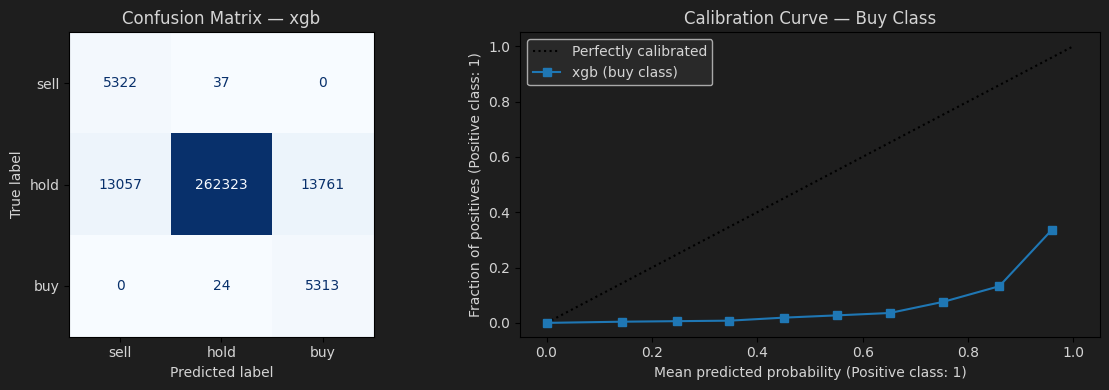

In [15]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.calibration import CalibrationDisplay

# ── Pick the best model (highest Macro F1 on selected features) ───────────────
_best_model_name = bench_df_sel['macro_f1'].idxmax()
_best_model      = fitted_models_sel[_best_model_name]
_best_X_te       = X_test_sel
_best_y_te       = y_test_xgb if _best_model_name in _XGB_MODELS else y_test
_best_preds      = _best_model.predict(_best_X_te)
if _best_model_name in _XGB_MODELS:
    _best_preds_orig = np.vectorize(_LABEL_REMAP.get)(_best_preds)
    _best_y_orig     = np.vectorize(_LABEL_REMAP.get)(_best_y_te)
    _cm_labels       = [-1, 0, 1]
else:
    _best_preds_orig = _best_preds
    _best_y_orig     = _best_y_te
    _cm_labels       = [-1, 0, 1]

print(f"Best model: {_best_model_name}")
print(f"\n{classification_report(_best_y_orig, _best_preds_orig, target_names=['sell','hold','buy'], zero_division=0)}")

# ── Confusion matrix ──────────────────────────────────────────────────────────
_cm = confusion_matrix(_best_y_orig, _best_preds_orig, labels=_cm_labels)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.patch.set_facecolor('#1e1e1e')

_disp = ConfusionMatrixDisplay(confusion_matrix=_cm, display_labels=['sell','hold','buy'])
_disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Confusion Matrix — {_best_model_name}', color='#d4d4d4')
axes[0].set_facecolor('#1e1e1e')
for _t in axes[0].get_xticklabels() + axes[0].get_yticklabels():
    _t.set_color('#d4d4d4')
axes[0].title.set_color('#d4d4d4')
axes[0].xaxis.label.set_color('#d4d4d4')
axes[0].yaxis.label.set_color('#d4d4d4')

# ── Calibration curve (binary: buy vs rest) ───────────────────────────────────
try:
    _proba = _best_model.predict_proba(_best_X_te)
    # buy class column
    _buy_col = 2 if _best_model_name in _XGB_MODELS else list(_best_model.classes_).index(1)
    _y_buy   = (_best_y_orig == 1).astype(int)
    CalibrationDisplay.from_predictions(
        _y_buy, _proba[:, _buy_col], n_bins=10,
        name=f'{_best_model_name} (buy class)', ax=axes[1]
    )
    axes[1].set_facecolor('#1e1e1e')
    axes[1].set_title('Calibration Curve — Buy Class', color='#d4d4d4')
    for _t in axes[1].get_xticklabels() + axes[1].get_yticklabels():
        _t.set_color('#d4d4d4')
    axes[1].title.set_color('#d4d4d4')
    axes[1].xaxis.label.set_color('#d4d4d4')
    axes[1].yaxis.label.set_color('#d4d4d4')
    axes[1].legend(facecolor='#2d2d2d', labelcolor='#d4d4d4')
except Exception as _e:
    axes[1].text(0.5, 0.5, f'Calibration unavailable\n{_e}',
                 ha='center', va='center', color='#d4d4d4', transform=axes[1].transAxes)

plt.tight_layout()
plt.show()


In [16]:
import textwrap, ast

# ── Preview selected features ─────────────────────────────────────────────────
_FEATURES_PY = os.path.join('Learn', 'features.py')
_FUNC_NAME   = f'_add_features_{SYMBOL}'

print(f"Selected features ({len(selected_features)}):")
for _i, _f in enumerate(selected_features, 1):
    print(f"  {_i:3d}. {_f}")

# ── Guard: check if function already exists ───────────────────────────────────
with open(_FEATURES_PY, 'r', encoding='utf-8') as _fp:
    _existing = _fp.read()

_safe_to_write = f'def {_FUNC_NAME}(' not in _existing
if not _safe_to_write:
    print(f"\n⚠  Function '{_FUNC_NAME}' already exists in {_FEATURES_PY}")
    print("   Set OVERWRITE_EXPORT = True below to replace it, or rename SYMBOL.")
else:
    print(f"\n✓  Function '{_FUNC_NAME}' not found — ready to export.")

OVERWRITE_EXPORT = True   # set True to overwrite an existing function

# ── Generate function source ──────────────────────────────────────────────────
_feat_list_repr = ',\n        '.join([f"'{f}'" for f in selected_features])
_func_source = f'''

def {_FUNC_NAME}(df: pd.DataFrame, include_mtf: bool = False, regime_params: dict = None) -> pd.DataFrame:
    """
    Add the features selected for {SYMBOL} by the Feature ML Lab.
    Generated automatically — edit with care.

    Pass regime_params to enable the causal market regime feature (fl_regime).

    Selected features ({len(selected_features)} total):
    {textwrap.fill(', '.join(selected_features), width=80, initial_indent='    ', subsequent_indent='    ')}
    """
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', pd.errors.PerformanceWarning)
        df = add_feature_library(df, include_mtf=include_mtf, regime_params=regime_params)
    df = df.copy()
    _keep = [
        c for c in [
        {_feat_list_repr},
        ]
        if c in df.columns
    ]
    # Retain OHLCV + Time columns alongside features
    _ohlcv = [c for c in ['Time', 'Open', 'High', 'Low', 'Close', 'Volume', 'target', 'sell_y', 'buy_y']
              if c in df.columns]
    _final = _ohlcv + [c for c in _keep if c not in _ohlcv]
    return df[_final]
'''

print(f"\nFunction preview (first 20 lines):")
for _i, _line in enumerate(_func_source.splitlines()[:20], 1):
    print(f"  {_i:3d} | {_line}")
print("  ...")

# ── Write to features.py ──────────────────────────────────────────────────────
def do_export():
    global _existing
    if not _safe_to_write and not OVERWRITE_EXPORT:
        print(f"✗  Skipped — '{_FUNC_NAME}' already exists. Set OVERWRITE_EXPORT=True to replace.")
        return

    if not _safe_to_write and OVERWRITE_EXPORT:
        # Remove existing function block
        import re
        _pattern = rf'\n\ndef {re.escape(_FUNC_NAME)}\(.*?(?=\n\ndef |\Z)'
        _existing = re.sub(_pattern, '', _existing, flags=re.DOTALL)

    _new_content = _existing.rstrip() + '\n' + _func_source
    with open(_FEATURES_PY, 'w', encoding='utf-8') as _fp:
        _fp.write(_new_content)
    print(f"\n✓  Written '{_FUNC_NAME}' to {_FEATURES_PY}")
    print(f"   Import with:  from Learn.features import {_FUNC_NAME}")

# ── Uncomment to export ───────────────────────────────────────────────────────
do_export()


Selected features (107):
    1. fl_regime
    2. fl_aroon_osc_14
    3. fl_close_vs_ema8
    4. fl_momentum_vote
    5. fl_pct_from_low_60
    6. MTF_5min_ll
    7. fl_stochrsi_14
    8. fl_macd_hist_norm
    9. fl_z_60
   10. fl_pct_from_high_60
   11. fl_rsi14_slope_3
   12. fl_di_minus
   13. fl_hl_range_atr
   14. MTF_5min_hh
   15. fl_stoch_k
   16. MTF_5min_slope
   17. fl_stoch_kd_diff
   18. fl_donchian_trend_60
   19. fl_di_plus
   20. fl_rv_10
   21. fl_squeeze_mom
   22. fl_mfi_14
   23. fl_ema_vote
   24. fl_price_loc_128
   25. MTF_5min_ema_dist
   26. fl_ret_lag_2
   27. fl_donchian_trend_5
   28. fl_macd_hist_slope_5
   29. fl_force_index_13
   30. fl_ichi_close_vs_kijun
   31. fl_ret_3
   32. fl_ichi_tk_diff
   33. fl_obv_slope_10
   34. MTF_5min_trend
   35. fl_pp_pos
   36. fl_close_loc
   37. fl_session_ny
   38. MTF_30min_ll
   39. fl_range_contract
   40. fl_roc_10
   41. fl_roc_5
   42. MTF_15min_hh
   43. MTF_15min_ll
   44. fl_rv_ratio_5_20
   45. fl_adx14
   46